# BIO-Compliance IRT — Results Walkthrough

This notebook loads every committed output file in the repository and explains
what it contains and how to read it. It is **self-contained**: it reads only
files tracked in git (the SQLite bank plus the JSON/JSONL outputs under
`evaluator/output/`), so it runs on a fresh clone with **no API calls and no
pipeline re-run**.

Sections mirror the pipeline stages:

1. **The item bank** (`compliance_bank.db`) — raw generated + real-world items
2. **Phase 1** — per-item difficulty `b` on the 45-cell grid
3. **Phase 2** — Rasch + classical QC → the frozen bank
4. **Phase 3a** — Δθ from prompt strictness (format vs. reasoning)
5. **Phase 3b** — Δθ from agent architecture (retrieval / critic / step-decomp)
6. **Judge audit** — the IRT judge vs. DeepEval G-Eval and RAGAS

Each section prints the key numbers and draws one figure. See `CLAUDE.md` §7 for
narrative state and `METHODOLOGY.md` for the reasoning behind each choice.

## 0. Setup

In [1]:
import json
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
# Allow running from repo root or from a notebooks/ subdir
if not (ROOT / 'compliance_bank.db').exists() and (ROOT.parent / 'compliance_bank.db').exists():
    ROOT = ROOT.parent
OUT = ROOT / 'evaluator' / 'output'

def load_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f if line.strip()]

def load_json(path):
    return json.loads(Path(path).read_text())

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print('repo root:', ROOT)
print('outputs :', OUT)

repo root: /home/user/BIO_Compliance_IRT
outputs : /home/user/BIO_Compliance_IRT/evaluator/output


## 1. The item bank — `compliance_bank.db`

The shared SQLite bank holds every generated item. `tasks` is the item text;
`calibration_results` holds the legacy 15-profile pass rates and logit-`b`.
Two `source_type`s: **synthetic** (LLM-generated, Red-Herring template) and
**real** (extracted from FDA warning letters).

In [2]:
conn = sqlite3.connect(f"file:{ROOT / 'compliance_bank.db'}?mode=ro", uri=True)
conn.row_factory = sqlite3.Row

n_total = conn.execute('SELECT COUNT(*) FROM tasks').fetchone()[0]
by_source = dict(conn.execute('SELECT source_type, COUNT(*) FROM tasks GROUP BY source_type').fetchall())
by_domain = pd.read_sql_query(
    'SELECT domain, source_type, COUNT(*) AS n FROM tasks GROUP BY domain, source_type', conn)

print(f'Total items: {n_total}')
print(f'By source  : {by_source}')

pivot = by_domain.pivot_table(index='domain', columns='source_type', values='n',
                              aggfunc='sum', fill_value=0)
pivot['total'] = pivot.sum(axis=1)
pivot = pivot.sort_values('total', ascending=False)
pivot

Total items: 1823
By source  : {'real': 105, 'synthetic': 1718}


source_type,real,synthetic,total
domain,,,
21cfr11,1,312,313
gmp_deviation,49,253,302
gcp_deviation,33,258,291
promo_review,12,257,269
informed_consent,10,253,263
easy_training,0,254,254
easy_consent,0,131,131


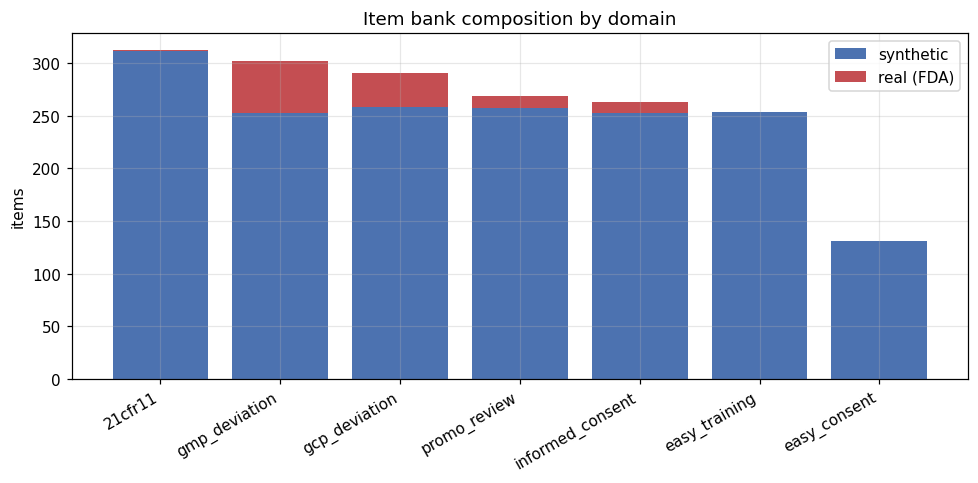

In [3]:
# Domain composition (synthetic vs real, stacked)
fig, ax = plt.subplots(figsize=(9, 4.5))
doms = pivot.index.tolist()
syn = pivot.get('synthetic', pd.Series(0, index=doms))
real = pivot.get('real', pd.Series(0, index=doms))
ax.bar(doms, syn, label='synthetic', color='#4C72B0')
ax.bar(doms, real, bottom=syn, label='real (FDA)', color='#C44E52')
ax.set_ylabel('items'); ax.set_title('Item bank composition by domain')
ax.legend(); plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

## 2. Phase 1 — per-item difficulty `b`  (`phase1_baseline_phase1_b.jsonl`)

Every item was attempted by a 45-cell virtual-examinee grid (3 models × 5
temperatures × 3 strictness levels), graded, and fit with a Rasch (1PL) model.
Each row is one item's anchored difficulty `b` (baseline examinee shifted to θ=0).
Higher `b` = harder.

items with a b estimate: 1823
min   -5.374
25%   -0.330
50%    2.442
75%    4.128
max    6.626


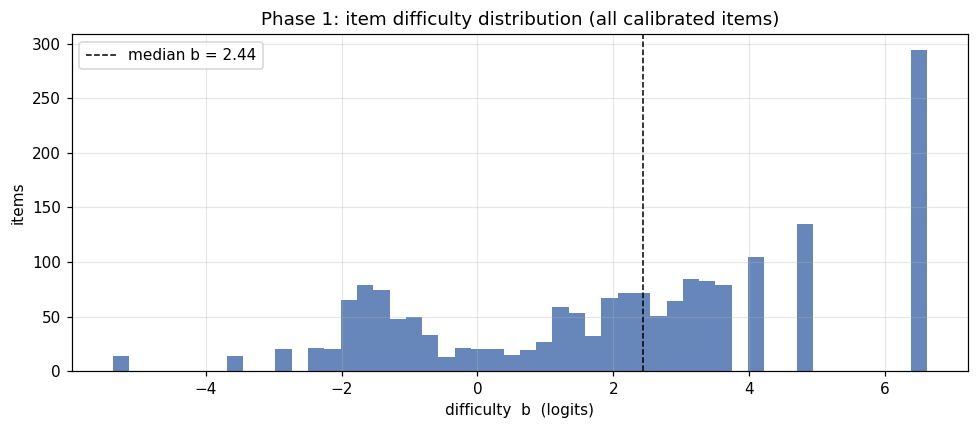

In [4]:
p1 = pd.DataFrame(load_jsonl(OUT / 'phase1_baseline_phase1_b.jsonl'))
print(f'items with a b estimate: {len(p1)}')
print(p1['b'].describe()[['min', '25%', '50%', '75%', 'max']].round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(p1['b'], bins=50, color='#4C72B0', alpha=0.85)
ax.axvline(p1['b'].median(), color='k', ls='--', lw=1,
           label=f"median b = {p1['b'].median():.2f}")
ax.set_xlabel('difficulty  b  (logits)'); ax.set_ylabel('items')
ax.set_title('Phase 1: item difficulty distribution (all calibrated items)')
ax.legend(); plt.tight_layout(); plt.show()

## 3. Phase 2 — Rasch + classical QC → frozen bank

`phase2_qc_report.json` records the QC funnel; `phase2_frozen_bank.jsonl` is the
surviving healthy bank with four columns per item: `b`, `point_biserial`,
`infit`, `outfit`. Items are dropped for zero-variance (all-pass/all-fail),
negative point-biserial (smarter examinees fail more → broken item), or
infit/outfit outside the accepted range.

In [5]:
qc = load_json(OUT / 'phase2_qc_report.json')
summary = qc['summary']
print('thresholds:', qc['thresholds'])
print(f"input items : {qc['n_items_input']}   examinees: {qc['n_examinees']}")
print(f"healthy     : {summary['n_healthy']}")
print(f"dropped     : {summary['n_dropped']}  ({summary['drop_rate']*100:.1f}%)")

# Tally drop reasons
from collections import Counter
reason_kind = Counter(v.split(' ')[0].split('(')[0] for v in qc['dropped_reasons'].values())
print('\ndrop reasons:')
for k, v in reason_kind.most_common():
    print(f'  {k:24s} {v}')

thresholds: {'pb_threshold': 0.0, 'infit_range': [0.0, 1.5], 'outfit_range': [0.0, 2.0]}
input items : 1823   examinees: 45
healthy     : 1284
dropped     : 539  (29.6%)

drop reasons:
  zero_variance            308
  low_point_biserial       155
  outfit_out_of_range      62
  infit_out_of_range       14


In [6]:
frozen = pd.DataFrame(load_jsonl(OUT / 'phase2_frozen_bank.jsonl'))
print(f'frozen items: {len(frozen)}')
frozen[['b', 'point_biserial', 'infit', 'outfit']].describe().round(3)

frozen items: 1284


,b,point_biserial,infit,outfit
count,1284.000,1284.000,1284.000,1284.000
mean,1.105,0.402,0.855,0.732
std,2.198,0.194,0.213,0.364
min,-4.250,0.004,0.382,0.152
25%,-1.082,0.241,0.703,0.493
50%,1.650,0.415,0.872,0.662
75%,2.707,0.567,1.001,0.893
max,4.249,0.757,1.494,1.978


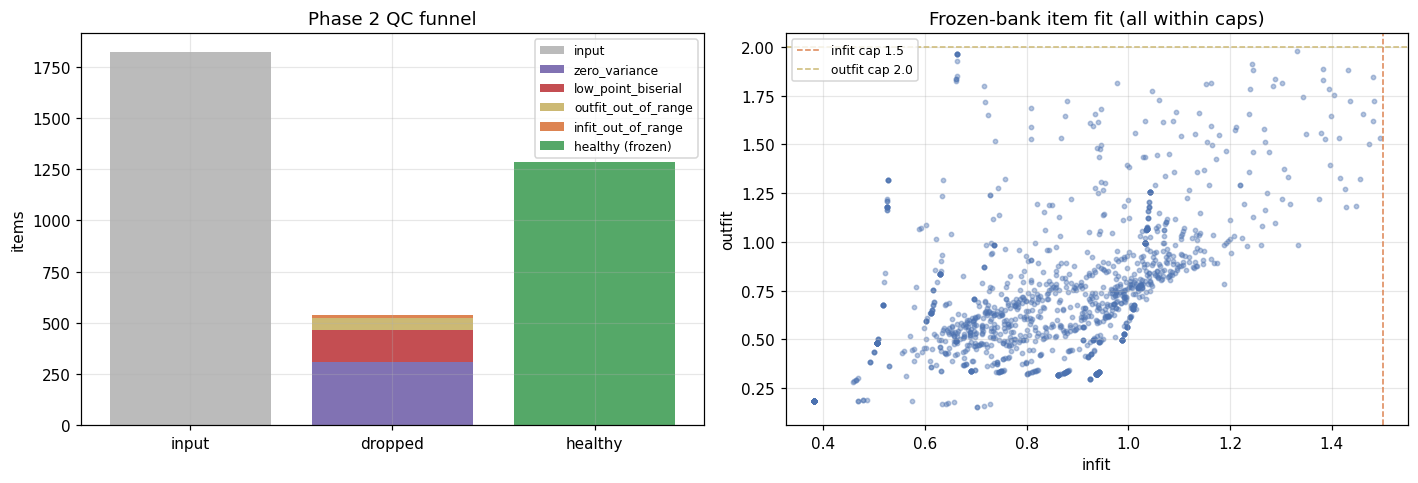

In [7]:
# QC drop funnel + healthy fit-stat distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# funnel
stages = ['input', 'healthy']
vals = [qc['n_items_input'], summary['n_healthy']]
axes[0].bar(['input'], [qc['n_items_input']], color='#BBBBBB', label='input')
bottom = 0
colors = {'zero_variance': '#8172B3', 'low_point_biserial': '#C44E52',
          'infit_out_of_range': '#DD8452', 'outfit_out_of_range': '#CCB974'}
for reason, n in reason_kind.most_common():
    axes[0].bar(['dropped'], [n], bottom=bottom, label=reason,
                color=colors.get(reason, '#999999'))
    bottom += n
axes[0].bar(['healthy'], [summary['n_healthy']], color='#55A868', label='healthy (frozen)')
axes[0].set_ylabel('items'); axes[0].set_title('Phase 2 QC funnel')
axes[0].legend(fontsize=8, loc='upper right')

# fit stats
axes[1].scatter(frozen['infit'], frozen['outfit'], s=8, alpha=0.4, color='#4C72B0')
axes[1].axvline(1.5, color='#DD8452', ls='--', lw=1, label='infit cap 1.5')
axes[1].axhline(2.0, color='#CCB974', ls='--', lw=1, label='outfit cap 2.0')
axes[1].set_xlabel('infit'); axes[1].set_ylabel('outfit')
axes[1].set_title('Frozen-bank item fit (all within caps)')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. Phase 3a — Δθ from prompt strictness  (`phase3a_strictness_deltatheta.json`)

How much does a stricter system prompt move a model's ability θ on the frozen
bank?  Measured under **two judges**:

- **strict** judge — requires section-level CFR/ICH citations
- **lenient** judge — conclusion + reasoning only, no citation needed

The gap between them is the **format-unlock** component: strict Δθ − lenient Δθ.
A large format-unlock means the prompt mostly taught the model to *cite*, not to
*reason*.

In [8]:
p3a = load_json(OUT / 'phase3a_strictness_deltatheta.json')
strict = p3a['delta_theta_vs_none_strict']
lenient = p3a['delta_theta_vs_none_lenient']
fmt = p3a['format_unlock_delta']

rows = []
for model in strict:
    rows.append({
        'model': model,
        'Δθ strict (none→strict)': round(strict[model]['strict'], 2),
        'Δθ lenient': round(lenient[model]['strict'], 2),
        'format-unlock': round(fmt[model]['strict'], 2),
        'reasoning gain': round(lenient[model]['strict'], 2),
    })
p3a_tbl = pd.DataFrame(rows).set_index('model')
p3a_tbl

,Δθ strict (none→strict),Δθ lenient,format-unlock,reasoning gain
model,,,,
llama-3.3-70b-versatile,5.41,2.52,2.89,2.52
openai/gpt-oss-20b,0.66,-0.23,0.89,-0.23
llama-3.1-8b-instant,1.69,0.18,1.52,0.18


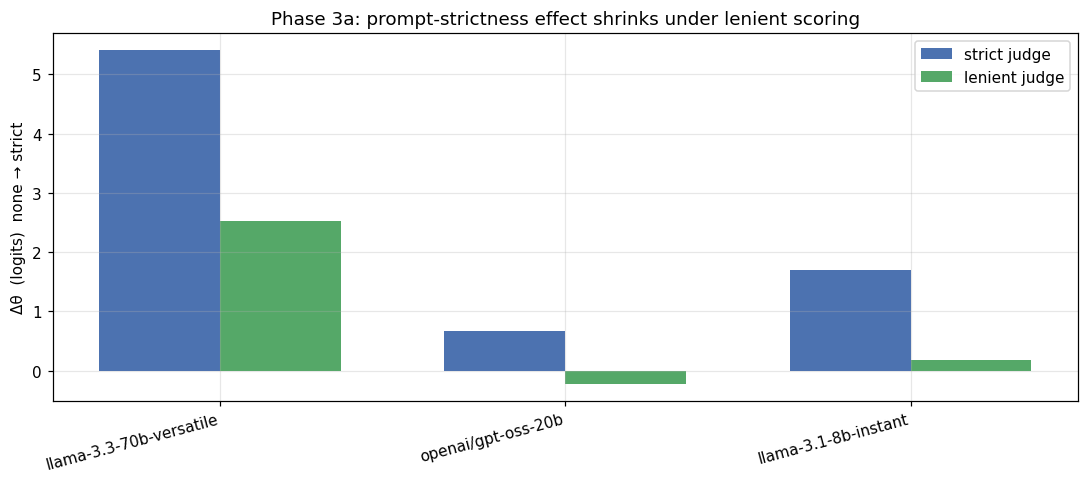

Reading: the gap between blue and green = format-unlock (citation, not reasoning).
Only llama-3.3-70b keeps a large lenient Δθ → genuine reasoning gain.


In [9]:
# Strict vs lenient Δθ (none→strict) per model
fig, ax = plt.subplots(figsize=(10, 4.5))
models = list(strict.keys())
x = np.arange(len(models)); w = 0.35
ax.bar(x - w/2, [strict[m]['strict'] for m in models], w, label='strict judge', color='#4C72B0')
ax.bar(x + w/2, [lenient[m]['strict'] for m in models], w, label='lenient judge', color='#55A868')
ax.set_xticks(x); ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_ylabel('Δθ  (logits)  none → strict')
ax.set_title('Phase 3a: prompt-strictness effect shrinks under lenient scoring')
ax.legend(); plt.tight_layout(); plt.show()

print('Reading: the gap between blue and green = format-unlock (citation, not reasoning).')
print('Only llama-3.3-70b keeps a large lenient Δθ → genuine reasoning gain.')

## 5. Phase 3b — Δθ from agent architecture  (`phase3b_agent_deltatheta.json`)

Instead of editing the prompt, swap the *agent*: `retrieval` (CFR vector lookup),
`critic` (self-review), `step_decomp` (4-step scaffold). `delta_rows` holds each
non-zero-shot cell's θ and its Δθ vs. the matching zero-shot cell.

In [10]:
p3b = load_json(OUT / 'phase3b_agent_deltatheta.json')
drows = pd.DataFrame(p3b['delta_rows'])
print('grid:', p3b['grid_config']['agent_types'], '×',
      p3b['grid_config']['models'], '× strictness', p3b['grid_config']['strictness_levels'])

tbl = (drows.pivot_table(index=['model', 'strictness'], columns='agent_type',
                         values='delta_theta_vs_zero_shot')
       .round(2))
tbl

grid: ['zero_shot', 'retrieval', 'critic', 'step_decomp'] × ['llama-3.3-70b-versatile', 'llama-3.1-8b-instant'] × strictness ['none', 'strict']


agent_type                          critic  retrieval  step_decomp
model                   strictness                                
llama-3.1-8b-instant    none         -0.03       0.35         0.65
                        strict       -0.67       0.09        -0.62
llama-3.3-70b-versatile none          3.45       1.07         4.55
                        strict       -0.94      -0.30        -0.51

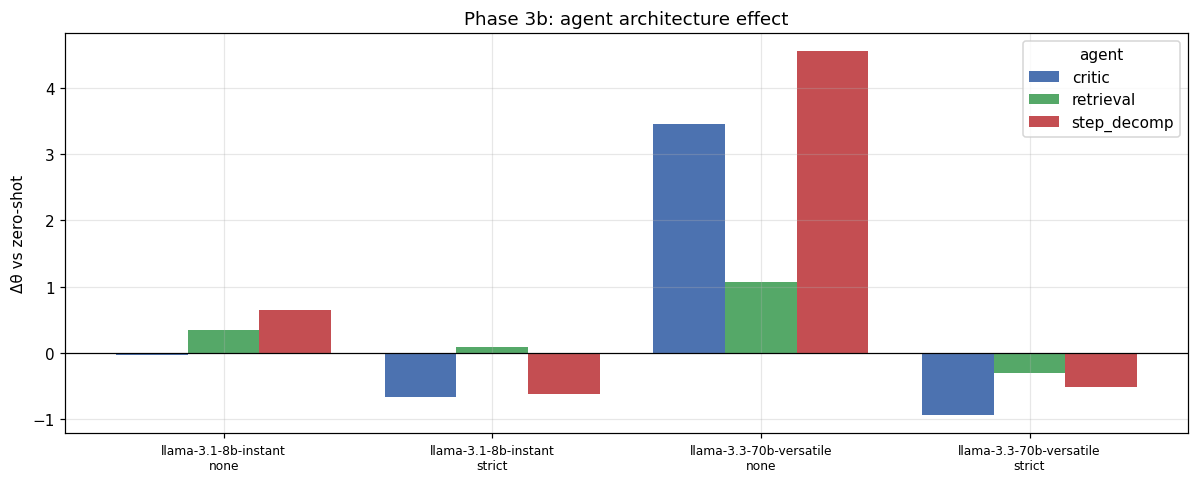

Same pattern as 3a: gains under lenient (none) scoring flip negative under strict.


In [11]:
# Δθ vs zero-shot, grouped by (model, strictness)
fig, ax = plt.subplots(figsize=(11, 4.5))
cells = [f'{m}\n{s}' for m, s in tbl.index]
agent_types = list(tbl.columns)
x = np.arange(len(cells)); w = 0.8 / len(agent_types)
palette = ['#4C72B0', '#55A868', '#C44E52', '#8172B3']
for i, a in enumerate(agent_types):
    ax.bar(x + i*w - 0.4 + w/2, tbl[a].values, w, label=a, color=palette[i % len(palette)])
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(cells, fontsize=8)
ax.set_ylabel('Δθ vs zero-shot'); ax.set_title('Phase 3b: agent architecture effect')
ax.legend(title='agent'); plt.tight_layout(); plt.show()

print('Same pattern as 3a: gains under lenient (none) scoring flip negative under strict.')

## 6. Judge audit — IRT judge vs. G-Eval and RAGAS  (`judge_audit_report.json`)

Do industry eval metrics agree with our IRT judge? 400 Phase 3b zero-shot
responses scored by four external metrics; each is compared to the IRT judge's
binary verdict via **AUC** (Mann-Whitney U / n₁n₂). AUC≈0.5 means the metric is
unrelated to our verdict; AUC→1.0 means it agrees.

In [12]:
rep = load_json(OUT / 'judge_audit_report.json')
print(f"responses audited: {rep['n_rows']}   disagreements dumped: {rep['n_disagreements_dumped']}")

rows = []
for metric, m in rep['metrics'].items():
    ds = m.get('difficulty_slope', {})
    rows.append({
        'metric': metric,
        'n': m['n_scored'],
        'AUC vs IRT': round(m['auc_vs_strict_judge'], 3),
        'point-biserial': round(m['point_biserial'], 3),
        'slope|PASS': round(ds.get('within_PASS', {}).get('slope', float('nan')), 3),
        'slope|FAIL': round(ds.get('within_FAIL', {}).get('slope', float('nan')), 3),
    })
audit_tbl = pd.DataFrame(rows).set_index('metric')
audit_tbl

responses audited: 400   disagreements dumped: 40


,n,AUC vs IRT,point-biserial,slope|PASS,slope|FAIL
metric,,,,,
geval_strict,400,0.838,0.570,0.015,-0.019
geval_lenient,400,0.731,0.381,-0.015,-0.052
ragas_faithfulness,363,0.530,0.057,-0.073,-0.056
ragas_answer_correctness,344,0.693,0.315,-0.003,-0.017


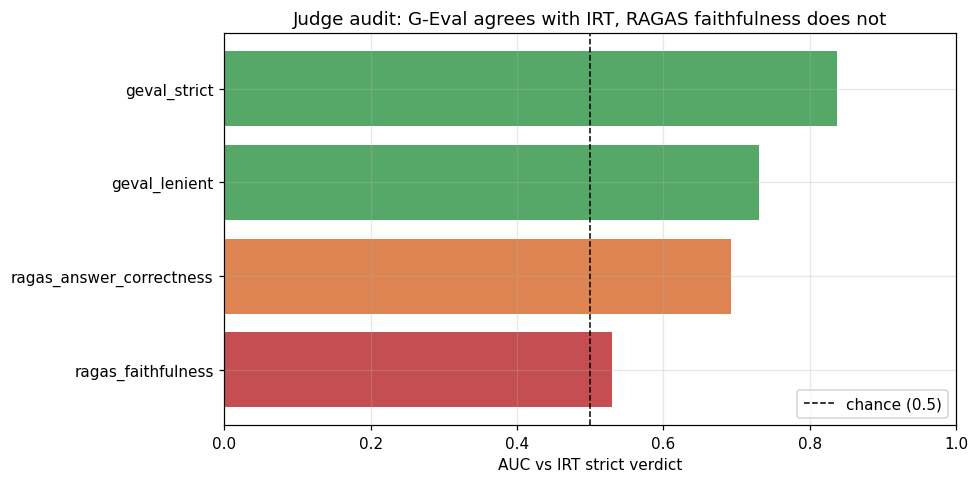

geval_strict (citation rubric) is the best external proxy for our judge.
ragas_faithfulness ~ 0.5: groundedness to context is a different construct from compliance correctness.


In [13]:
# AUC bar with chance line
fig, ax = plt.subplots(figsize=(9, 4.5))
order = audit_tbl.sort_values('AUC vs IRT', ascending=False)
colors = ['#55A868' if v >= 0.7 else '#DD8452' if v >= 0.6 else '#C44E52'
          for v in order['AUC vs IRT']]
ax.barh(order.index[::-1], order['AUC vs IRT'][::-1], color=colors[::-1])
ax.axvline(0.5, color='k', ls='--', lw=1, label='chance (0.5)')
ax.set_xlabel('AUC vs IRT strict verdict'); ax.set_xlim(0, 1)
ax.set_title('Judge audit: G-Eval agrees with IRT, RAGAS faithfulness does not')
ax.legend(); plt.tight_layout(); plt.show()

print('geval_strict (citation rubric) is the best external proxy for our judge.')
print('ragas_faithfulness ~ 0.5: groundedness to context is a different construct',
      'from compliance correctness.')

In [14]:
# Peek at a few IRT-vs-G-Eval disagreements (qualitative)
dis = load_jsonl(OUT / 'judge_audit_disagreements.jsonl')
print(f'{len(dis)} disagreement cases logged. Example kinds:')
from collections import Counter
for kind, n in Counter(d['kind'] for d in dis).items():
    print(f'  {kind}: {n}')

ex = dis[0]
print('\n--- example ---')
print('kind        :', ex['kind'])
print('domain      :', ex['domain'])
print('geval score :', round(ex['geval_strict_score'], 3), ' IRT verdict:', ex['irt_judge_verdict'])
print('IRT reason  :', ex['irt_judge_reason'][:200])

40 disagreement cases logged. Example kinds:
  high_geval_but_judge_FAIL: 20
  low_geval_but_judge_PASS: 20

--- example ---
kind        : high_geval_but_judge_FAIL
domain      : gmp_deviation
geval score : 0.9  IRT verdict: 0
IRT reason  : The response does not perfectly align with the gold standard's substantive compliance reasoning, as it incorrectly cites 21 CFR 211.165(f) and mixes the key obligation with additional, albeit relevant


## 7. Takeaways

- **The bank** is 1,823 calibrated items (1,718 synthetic + 105 real); Phase 2 QC
  freezes **1,284 healthy** items (≈70%).
- **Prompt strictness** moves θ a lot under a citation-requiring judge, but the
  lenient re-grade shows most of that is **citation format**, not reasoning —
  except llama-3.3-70b, which keeps a real reasoning gain (~+2.5 logits).
- **Agent architecture** (retrieval/critic/step-decomp) shows the *same* pattern:
  gains under lenient scoring, losses under strict.
- **The judge audit** validates the IRT judge externally: a citation-rubric
  G-Eval tracks it at AUC=0.84, while RAGAS faithfulness (≈0.53) confirms
  groundedness ≠ correctness.

All numbers above are read directly from committed files — re-run this notebook
any time to reproduce the current state.